Matplotlib is building the font cache; this may take a moment.


Original Data Matrix:
 [[150.     0.9    0.4 ]
 [145.     0.88   0.45]
 [140.     0.85   0.5 ]
 [110.     0.6    0.8 ]
 [105.     0.55   0.85]
 [100.     0.5    0.9 ]
 [ 90.     0.7    0.9 ]
 [ 85.     0.65   0.95]
 [ 95.     0.75   0.85]
 [ 60.     0.3    0.2 ]
 [ 55.     0.25   0.15]
 [ 65.     0.35   0.25]]

RREF of Data Matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Covariance Matrix:
 [[1.04090909e+03 6.48636364e+00 1.95454545e+00]
 [6.48636364e+00 5.02606061e-02 2.55000000e-02]
 [1.95454545e+00 2.55000000e-02 9.31818182e-02]]

Eigenvalues:
 [1.04095318e+03 9.16790386e-02 7.67287636e-03]

Eigenvectors:
 [[ 0.99997882  0.00285455 -0.00584879]
 [ 0.00623139 -0.1606312   0.98699483]
 [ 0.00187793 -0.98701037 -0.16064558]]

Orthogonality Check (dot product):
6.505213034913027e-19

Enter song features:

Distances:
Rock: 54.9995
Pop: 95.0006
Hip-Hop: 109.9996
Classical: 140.0018

🎧

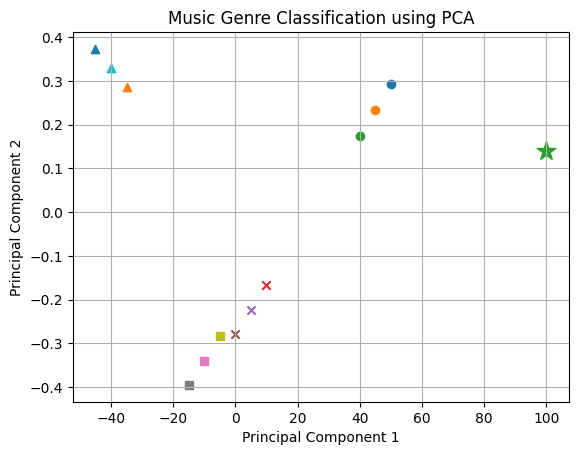

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Matrix

# -------------------------------
# STEP 1: DATA (4 Genres)
# -------------------------------

X = np.array([
    # Rock
    [150, 0.9, 0.4],
    [145, 0.88, 0.45],
    [140, 0.85, 0.5],

    # Pop
    [110, 0.6, 0.8],
    [105, 0.55, 0.85],
    [100, 0.5, 0.9],

    # Hip-Hop
    [90, 0.7, 0.9],
    [85, 0.65, 0.95],
    [95, 0.75, 0.85],

    # Classical
    [60, 0.3, 0.2],
    [55, 0.25, 0.15],
    [65, 0.35, 0.25]
])

labels = ["Rock"]*3 + ["Pop"]*3 + ["Hip-Hop"]*3 + ["Classical"]*3

print("Original Data Matrix:\n", X)

# -------------------------------
# STEP 2: RREF (Matrix Simplification)
# -------------------------------

print("\nRREF of Data Matrix:")
rref_matrix, _ = Matrix(X).rref()
print(np.array(rref_matrix, dtype=float))

# -------------------------------
# STEP 3: MEAN CENTERING
# -------------------------------

mean = np.mean(X, axis=0)
X_centered = X - mean

# -------------------------------
# STEP 4: COVARIANCE MATRIX
# -------------------------------

cov_matrix = np.cov(X_centered, rowvar=False)
print("\nCovariance Matrix:\n", cov_matrix)

# -------------------------------
# STEP 5: EIGENVALUES & EIGENVECTORS
# -------------------------------

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by importance
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

# -------------------------------
# STEP 6: ORTHOGONAL BASIS CHECK
# -------------------------------

print("\nOrthogonality Check (dot product):")
print(np.dot(eigenvectors[:, 0], eigenvectors[:, 1]))

# -------------------------------
# STEP 7: PCA (DIMENSION REDUCTION)
# -------------------------------

W = eigenvectors[:, :2]
X_reduced = X_centered @ W

# -------------------------------
# STEP 8: USER INPUT
# -------------------------------

print("\nEnter song features:")

tempo = float(input("Tempo: "))
energy = float(input("Energy (0 to 1): "))
dance = float(input("Danceability (0 to 1): "))

new_song = np.array([tempo, energy, dance])
new_song_centered = new_song - mean
new_song_reduced = new_song_centered @ W

# -------------------------------
# STEP 9: GENRE CENTERS
# -------------------------------

rock_center = np.mean(X_reduced[0:3], axis=0)
pop_center = np.mean(X_reduced[3:6], axis=0)
hiphop_center = np.mean(X_reduced[6:9], axis=0)
classical_center = np.mean(X_reduced[9:12], axis=0)

centers = {
    "Rock": rock_center,
    "Pop": pop_center,
    "Hip-Hop": hiphop_center,
    "Classical": classical_center
}

# -------------------------------
# STEP 10: CLASSIFICATION
# -------------------------------

min_dist = float('inf')
predicted = ""

print("\nDistances:")

for genre, center in centers.items():
    dist = np.linalg.norm(new_song_reduced - center)
    print(f"{genre}: {dist:.4f}")
    if dist < min_dist:
        min_dist = dist
        predicted = genre

print("\n🎧 Predicted Genre:", predicted)

# -------------------------------
# STEP 11: VISUALIZATION
# -------------------------------

for i, point in enumerate(X_reduced):
    if labels[i] == "Rock":
        plt.scatter(point[0], point[1], marker='o')
    elif labels[i] == "Pop":
        plt.scatter(point[0], point[1], marker='x')
    elif labels[i] == "Hip-Hop":
        plt.scatter(point[0], point[1], marker='s')
    else:
        plt.scatter(point[0], point[1], marker='^')

# Plot new song
plt.scatter(new_song_reduced[0], new_song_reduced[1], marker='*', s=200)

plt.title("Music Genre Classification using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()

plt.show()